# Convolutional Contractive Autoencoder

Train the convolutional autoencoder with a contractive penalty on the encoder Jacobian.


## Key Idea

Contractive AE penalizes encoder sensitivity, not an input noise distribution or latent prior.

$$
\mathcal{L}(x) = \mathrm{MSE}(g(f(x)), x) + \lambda \left\|J_f(x)\right\|_F^2
$$

- `f(x)`: encoder, `h = f(x)`
- `g(h)`: decoder reconstruction
- `J_f(x) = dh/dx`: encoder Jacobian
- `contractive_lambda`: strength of the contractive penalty
- `hutchinson_samples`: number of random vectors used to estimate the Jacobian norm


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()  # tensor(0.) tensor(1.)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5), (0.5))
# ])  # -> tensor(-1.) tensor(1.) for tanh activation function

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data,
                                          batch_size=64,
                                          shuffle=True)

In [3]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Reduce the size
        # N(=batch size), 784(=28x28)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)  # -> N, 3
        )

        self.decoder = nn.Sequential(
            # N, 3 -> N, 784

            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Activation Funciton
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        
        super().__init__()
        self.encoder = nn.Sequential(
            # N, 1, 28, 28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # N, 16, 14, 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7) # stride=1, padding=0 # N, 64, 1, 1
        )

        self.decoder = nn.Sequential(
            # N, 64, 1, 1
            nn.ConvTranspose2d(64, 32, 7), # N, 32, 7, 7
            nn.ReLU(),           
            # IMPORTNAT! use output_padding to produce output spatial size 14, not 13
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh
# nn.MaxPool2d <-> nn.MaxUnpool2d

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

contractive_lambda = 1e-4
hutchinson_samples = 1

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Using device: cuda
NVIDIA GeForce RTX 5080


In [7]:
def contractive_penalty(h, x, num_samples=1):
    """Estimate ||dh/dx||_F^2 with Hutchinson's estimator."""
    penalty = 0.0
    h_flat = h.view(h.size(0), -1)

    for _ in range(num_samples):
        v = torch.randn_like(h_flat)
        hv = torch.sum(h_flat * v)
        grad = torch.autograd.grad(
            hv,
            x,
            create_graph=True,
            retain_graph=True,
            only_inputs=True,
        )[0]
        penalty = penalty + grad.pow(2).view(grad.size(0), -1).sum(dim=1).mean()

    return penalty / num_samples

In [8]:
num_epochs = 10
outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        img.requires_grad_(True)

        h = model.encoder(img)
        recon = model.decoder(h)

        recon_loss = criterion(recon, img)
        contraction_loss = contractive_penalty(h, img, hutchinson_samples)
        loss = recon_loss + contractive_lambda * contraction_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(
        f'Epoch:{epoch + 1}, '
        f'Loss:{loss.item():.4f}, '
        f'Recon:{recon_loss.item():.4f}, '
        f'Contractive:{contraction_loss.item():.4f}'
    )
    outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))  # original image, reconstructed image

Epoch:1, Loss:0.0133, Recon:0.0118, Contractive:14.6292
Epoch:2, Loss:0.0065, Recon:0.0058, Contractive:7.8015
Epoch:3, Loss:0.0047, Recon:0.0041, Contractive:5.9214
Epoch:4, Loss:0.0046, Recon:0.0041, Contractive:5.2375
Epoch:5, Loss:0.0047, Recon:0.0043, Contractive:3.8654
Epoch:6, Loss:0.0036, Recon:0.0030, Contractive:5.1634
Epoch:7, Loss:0.0037, Recon:0.0032, Contractive:4.7350
Epoch:8, Loss:0.0042, Recon:0.0038, Contractive:4.0615
Epoch:9, Loss:0.0041, Recon:0.0037, Contractive:4.2891
Epoch:10, Loss:0.0037, Recon:0.0033, Contractive:3.5544


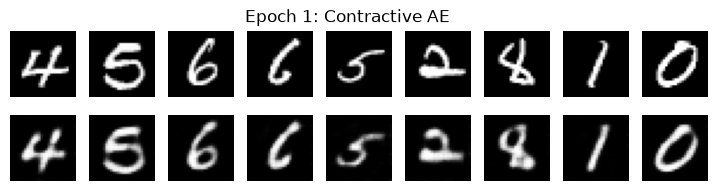

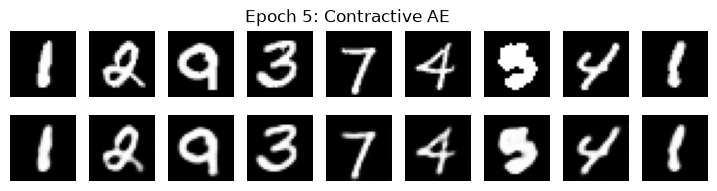

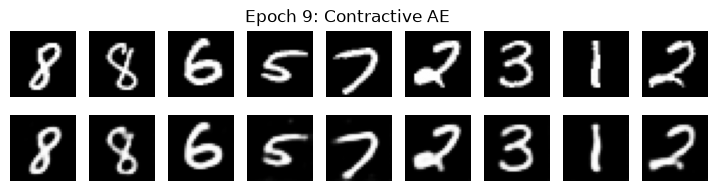

In [9]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].numpy()
    recon = outputs[k][2].numpy()

    for i, item in enumerate(imgs[:9]):
        ax = plt.subplot(2, 9, i + 1)
        ax.imshow(item.reshape(28, 28))
        ax.axis("off")
        if i == 0:
            ax.set_ylabel("clean", rotation=0, labelpad=24, va="center")

    for i, item in enumerate(recon[:9]):
        ax = plt.subplot(2, 9, 9 + i + 1)
        ax.imshow(item.reshape(28, 28))
        ax.axis("off")
        if i == 0:
            ax.set_ylabel("recon", rotation=0, labelpad=24, va="center")

    plt.suptitle(f"Epoch {outputs[k][0] + 1}: Contractive AE")
    plt.show()